# FinanceBench Notebook


## Imports and Config

In [1]:
# Step 0: setup imports and configuration

from time import perf_counter
import json
import pandas as pd
from src.financebench_rag.config import load_config
from src.financebench_rag.dataset import build_doc_metadata_table, prepare_stage1_dataset
from src.financebench_rag.evaluation import (
    compute_correctness_judgements,
    compute_faithfulness_first_20,
    compute_page_hit_rate,
)
from src.financebench_rag.utils.io_utils import save_dataframe_csv, save_dataframe_json, save_json
from src.financebench_rag.naive_generation import run_naive_generation, sample_stage2_questions
from src.financebench_rag.rag_pipeline import RAGPipeline
from src.financebench_rag.retrieval_checks import run_retrieval_sanity_checks
from src.financebench_rag.vectorstore import (
    build_or_load_vectorstore,
    chunk_documents,
    download_required_pdfs,
    load_pdf_pages_with_metadata,
)

config = load_config()
config.results_dir.mkdir(parents=True, exist_ok=True)
config.pdf_dir.mkdir(parents=True, exist_ok=True)
config.vectorstore_dir.mkdir(parents=True, exist_ok=True)

print('Loaded config')
print(config)

Loaded config
PipelineConfig(dataset_id='PatronusAI/financebench', dataset_split='train', api_base_url='https://api.tokenfactory.nebius.com/v1', api_key='v1.CmQKHHN0YXRpY2tleS1lMDBkZW4xNGJ2aGs1YWowZ2ESIXNlcnZpY2VhY2NvdW50LWUwMHg4ZGVyazh0dHJ5cTFlNDIMCOydpM4GEPPH3eoCOgwI66C8mQcQwOPnmQJAAloDZTAw.AAAAAAAAAAEkdoZogNdkUIy462oJv3-9F7IqWb2jOKx_1MgpIoV8BcE0g41S1owg6ZSpgi9W28qsNb8GO3_ILQYFAW2-DSUF', generation_model='meta-llama/Llama-3.3-70B-Instruct', judge_model='deepseek-ai/DeepSeek-V3.2', ragas_model='deepseek-ai/DeepSeek-V3.2', embedding_model='BAAI/bge-small-en-v1.5', chunk_size=1000, chunk_overlap=150, retrieval_default_k=10, retrieval_hit_k_values=[1, 3, 5], data_dir=WindowsPath('data'), pdf_dir=WindowsPath('data/pdfs'), vectorstore_dir=WindowsPath('vectorstore/optimized'), results_dir=WindowsPath('results'), rerank_enabled=False, rerank_top_k=20, rerank_final_k=4)


***

## Load Dataset

In [2]:
# Step 1: load and filter dataset
# Creates filtered FinanceBench rows and repaired doc-link mapping.

t0 = perf_counter()
filtered_df, doc_mapping_df = prepare_stage1_dataset(
    dataset_id=config.dataset_id,
    split=config.dataset_split,
    output_dir=config.results_dir,
)

save_dataframe_csv(filtered_df, config.results_dir / 'stage1_filtered.csv')
save_dataframe_json(filtered_df, config.results_dir / 'stage1_filtered.json')
save_dataframe_csv(doc_mapping_df, config.results_dir / 'stage1_doc_mapping.csv')
save_dataframe_json(doc_mapping_df, config.results_dir / 'stage1_doc_mapping.json')

print(f'Stage 1 complete in {perf_counter() - t0:.1f}s')
print('Filtered rows:', len(filtered_df))
print('Doc mapping rows:', len(doc_mapping_df))
filtered_df[['financebench_id', 'question_type', 'doc_name', 'evidence_page_nums']].head()

Stage 1 complete in 2.4s
Filtered rows: 100
Doc mapping rows: 42


,financebench_id,question_type,doc_name,evidence_page_nums
0,financebench_id_00005,domain-relevant,CORNING_2022_10K,[59]
1,financebench_id_00070,domain-relevant,AMERICANWATERWORKS_2022_10K,"[80, 81]"
2,financebench_id_00080,domain-relevant,PAYPAL_2022_10K,[60]
3,financebench_id_00206,domain-relevant,JPMORGAN_2022_10K,[2]
4,financebench_id_00215,domain-relevant,VERIZON_2022_10K,"[22, 55]"


## `Part 1`

### Run Naive Generation on stage 2 questions (no retrieval, no RAG)

In [3]:
stage2_questions = sample_stage2_questions(filtered_df, n_per_type=10) # We chose 10 per type instead for better representation

In [3]:
# Step 2: run naive generation on sampled questions
# Samples a small set per type and generates baseline answers without retrieval.
t0 = perf_counter()
naive_df = run_naive_generation(stage2_questions, config)

save_dataframe_csv(naive_df, config.results_dir / 'stage2_naive.csv')
save_dataframe_json(naive_df, config.results_dir / 'stage2_naive.json')

print(f'Stage 2 complete in {perf_counter() - t0:.1f}s')
print('Sampled questions:', len(stage2_questions))
naive_df.head()

NameError: name 'stage2_questions' is not defined

**We'll analyze for both Naive Generation and Rag Generation the answers w.r.t ground truth and question type**

***

## `Part 2`

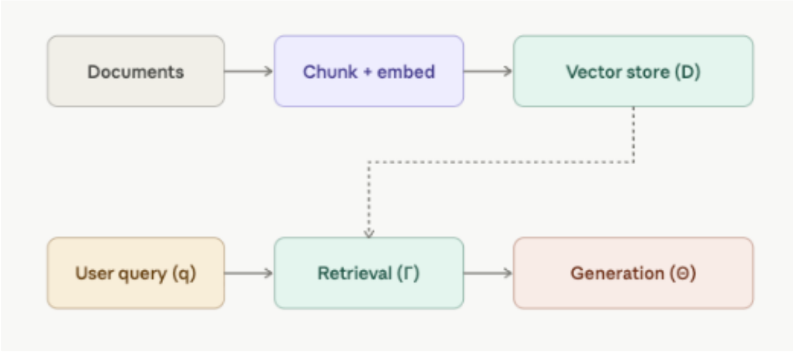

**The Three components:**

A. indexing (documents → chunk + embed → vector store) 

B. retrieval (user query → retrieval)

C. generation

 For each component, briefly explain:

1. How does it contribute to the pipeline?

    a. Indexing, makes the model get only the important information (Chunks) and not get irrelevant context. When a question is presented, because we embedded the chunks we fetch the most relevant chunk based on the embedding. All this information is stored in an offline wrapper that is convenient and fast to use. 
    
    b. Retrieval connects the user's query and the knowledge base. The query is embedded using the same model as the chunks and the system finds the nearest vectors — essentially asking "which stored meaning is geometrically closest to the question's meaning?" The retrieved chunks are then handed to the generator as pertinent context.

    c. The LLM, which is a model with vast knowledge and language abilities get the retrieved chunks and generates an answer that uses relevant information and fits the question.

2. Where can it fail? Try to think of concrete examples
    
    a. 
    - If chunks are too large it can confuse the generator
    - If chunks are too small it can hide inportant information from the model
    - Chunking at wrong boundaries can cut siginificant information.
    - Weak embedding model cannot create the important vector space for similarities.
    - uninformative raw documents or errors in the documents.

    b. 
    - Query and document vocabulary mismatch
    - Top k does not fit the knowledge base and the query.
    - Queries that require 2-step answer.

3. Does it happen once ("offline"), or per query?
    a. Happens offline
    b. Per query, everytime a user sends a question
    c. Per query, everytime a user sends a question

***

## `Part 3`

**The code is contained in vectorstore.py**

### Loading saved vectorstore

In [5]:
# Step 3: prepare or load vectorstore (safe cache check)
t0 = perf_counter()

faiss_file = config.vectorstore_dir / "index.faiss"
pkl_file = config.vectorstore_dir / "index.pkl"
has_complete_cache = faiss_file.exists() and pkl_file.exists()

if has_complete_cache:
    print(f"Reusing cached vectorstore from {config.vectorstore_dir}")
    vectorstore = build_or_load_vectorstore([], config)
    pages = []
    chunks = []
else:
    if faiss_file.exists() and not pkl_file.exists():
        print("Found incomplete cache (index.faiss without index.pkl). Rebuilding.")
    else:
        print("No cached index found. Building vectorstore from source PDFs")

    doc_table = build_doc_metadata_table(filtered_df)
    _ = download_required_pdfs(doc_table["doc_name"].tolist(), config.pdf_dir)
    pages = load_pdf_pages_with_metadata(doc_table, config.pdf_dir)
    chunks = chunk_documents(
        pages,
        chunk_size=config.chunk_size,
        chunk_overlap=config.chunk_overlap,
    )
    vectorstore = build_or_load_vectorstore(chunks, config)

print(f"Stage 3 complete in {perf_counter() - t0:.1f}s")
if chunks:
    print("Chunks created:", len(chunks))

Reusing cached vectorstore from vectorstore


c:\Users\maorb\work\rag_project\src\financebench_rag\vectorstore.py:134: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading existing vectorstore from vectorstore ...
Stage 3 complete in 5.3s


***

In [13]:
# Step 3b: retrieval sanity checks
# Verifies retrieved pages/docs on a tiny sample before full evaluation.

t0 = perf_counter()
sanity_input = filtered_df.head(3)
sanity_df = run_retrieval_sanity_checks(sanity_input, vectorstore, k=config.retrieval_default_k)
save_dataframe_csv(sanity_df, config.results_dir / 'stage3_sanity_checks.csv')
save_dataframe_json(sanity_df, config.results_dir / 'stage3_sanity_checks.json')

print(f'Stage 3b complete in {perf_counter() - t0:.1f}s')
sanity_df.head()

Stage 3b complete in 0.1s


,financebench_id,question,rank,expected_doc_name,retrieved_doc_name,doc_match,expected_pages,retrieved_page_number,page_match,evidence_text_approx_match
0,financebench_id_00005,Does Corning have positive working capital bas...,1,CORNING_2022_10K,CORNING_2022_10K,True,[59],101,False,False
1,financebench_id_00005,Does Corning have positive working capital bas...,2,CORNING_2022_10K,CORNING_2022_10K,True,[59],102,False,False
2,financebench_id_00005,Does Corning have positive working capital bas...,3,CORNING_2022_10K,3M_2022_10K,False,[59],37,False,False
3,financebench_id_00005,Does Corning have positive working capital bas...,4,CORNING_2022_10K,3M_2023Q2_10Q,False,[59],70,False,False
4,financebench_id_00005,Does Corning have positive working capital bas...,5,CORNING_2022_10K,CORNING_2022_10K,True,[59],90,False,False


## `Part 4`

### Generation using Rag

In [14]:
# Step 4: run RAG on stage2 sampled questions
# Builds RAG outputs for the same sample used by naive baseline.

t0 = perf_counter()
rag = RAGPipeline(config=config, vectorstore=vectorstore)
rag_stage2_df = rag.run_on_dataframe(stage2_questions, k=config.retrieval_default_k)
save_dataframe_csv(rag_stage2_df, config.results_dir / 'stage4_rag_stage2_questions.csv')
save_dataframe_json(rag_stage2_df, config.results_dir / 'stage4_rag_stage2_questions.json')

print(f'Stage 4 complete in {perf_counter() - t0:.1f}s')
rag_stage2_df.head()

Stage 4 complete in 72.8s


,financebench_id,question,ground_truth,rag_answer,retrieved_chunks
0,financebench_id_00005,Does Corning have positive working capital bas...,Yes. Corning had a positive working capital am...,The context is insufficient to determine if Co...,"[{'doc_name': 'CORNING_2022_10K', 'page_number..."
1,financebench_id_00070,Does American Water Works have positive workin...,"No, American Water Works had negative working ...",The context is insufficient to determine if Am...,"[{'doc_name': 'AMERICANWATERWORKS_2022_10K', '..."
2,financebench_id_00080,Does Paypal have positive working capital base...,Yes. Paypal has a positive working capital of ...,To determine if Paypal has positive working ca...,"[{'doc_name': 'PAYPAL_2022_10K', 'page_number'..."
3,financebench_id_00206,Are JPM's gross margins historically consisten...,"Since JPM is a financial institution, gross ma...",The context is insufficient to determine if JP...,"[{'doc_name': 'BESTBUY_2023_10K', 'page_number..."
4,financebench_id_00215,Is Verizon a capital intensive business based ...,Yes. Verizon's capital intensity ratio was app...,"Based on the provided context, specifically Ch...","[{'doc_name': 'VERIZON_2021_10K', 'page_number..."


In [24]:
from IPython.display import display, Markdown, HTML

html = (
    rag_stage2_df[["ground_truth", "rag_answer"]]
    .fillna("")
    .assign(
        rag_answer=lambda d: d["rag_answer"]
        .astype(str)
        .str.replace("\n", "<br>", regex=False)
    )
    .to_html(escape=False, index=False)
)

display(HTML(html))

ground_truth,rag_answer
Yes. Corning had a positive working capital amount of $831 million by FY 2022 close. This answer considers only operating current assets and current liabilities that were clearly shown in the balance sheet.,The context is insufficient to determine if Corning has positive working capital based on FY2022 data. The provided chunks do not contain Corning's working capital information or its current assets and liabilities for FY2022.
"No, American Water Works had negative working capital of -$1561M in FY 2022.","The context is insufficient to determine if American Water Works has positive working capital based on FY2022 data. The provided chunks do not contain the necessary information to calculate working capital, which is typically defined as current assets minus current liabilities. While Chunk 1 provides some information on current liabilities, it does not provide information on current assets."
Yes. Paypal has a positive working capital of $ 1.6Bn as of FY2022 end.,"To determine if Paypal has positive working capital based on FY2022 data, we need to calculate working capital, which is typically defined as current assets minus current liabilities.From Chunk 8 (doc_name: PAYPAL_2022_10K, page 60), we have the necessary data:- Total current assets: $57,517 million- Total current liabilities: $45,101 millionWorking capital = Total current assets - Total current liabilitiesWorking capital = $57,517 million - $45,101 millionWorking capital = $12,416 millionSince the working capital is positive ($12,416 million), the answer is yes, Paypal has positive working capital based on FY2022 data. Source: PAYPAL_2022_10K, page 60."
"Since JPM is a financial institution, gross margin is not a relevant metric.",The context is insufficient to determine if JPM's gross margins are historically consistent. None of the provided chunks contain information about JPM's gross margins or their year-over-year fluctuations.
"Yes. Verizon's capital intensity ratio was approximately 2.774729. This means that it took approximately $2.77 of assets to generate $1 of revenue and thus, Verizon can be considered capital intensive.","Based on the provided context, specifically Chunk 3 from the ""VERIZON_2022_10K"" document, Verizon invested $23.1 billion in capital expenditures in 2022. This significant investment in capital expenditures suggests that Verizon is a capital-intensive business. (Source: VERIZON_2022_10K, page 22)"
No. The quick ratio was approximately 0.54 for Verizon. It indicated that Verizon does not have a healthy liquidity profile.,"The context is insufficient to determine if Verizon has a reasonably healthy liquidity profile based on its quick ratio for FY 2022, as the quick ratio is not provided in the given chunks."
"Yes. The quick ratio is 1.57, calculated as (cash and cash equivalents+Short term investments+Accounts receivable, net+receivables from related parties)/ (current liabilities).","The context is insufficient to determine if AMD has a reasonably healthy liquidity profile based on its quick ratio for FY22, as the provided chunks do not contain AMD's quick ratio or any relevant liquidity metrics for FY22."
No the operating margins of Adobe have recently declined from 36.8% in FY 2021 to 34.6% in FY2022. A drop by 2.2% in a year.,"The context is insufficient to determine if Adobe has an improving operating margin profile as of FY2022. Although Chunk 4 (doc_name: ADOBE_2022_10K, page_number: 53) provides Adobe's financial statements, including operating income, it does not provide a direct comparison of operating margins between FY2022 and previous years."
There are none,The context is insufficient to determine which debt securities are registered to trade on a national securities exchange under American Express' name as of 2022. The provided chunks do not contain specific information about debt securities registered for trading on a national securities exchange.
"No, the company is managing its CAPEX and Fixed A

## `Part 5 + Explainability of Part 1`

In [25]:
# Step 5: build side-by-side comparison
# Joins ground truth, naive output, and RAG output for quick manual inspection.

from src.financebench_rag.comparison import build_side_by_side_table

t0 = perf_counter()
comparison_df = build_side_by_side_table(stage2_questions, naive_df, rag_stage2_df)
save_dataframe_csv(comparison_df, config.results_dir / 'stage5_comparison.csv')
save_dataframe_json(comparison_df, config.results_dir / 'stage5_comparison.json')

print(f'Stage 5 complete in {perf_counter() - t0:.1f}s')
comparison_df.head(10)

Stage 5 complete in 0.2s


,financebench_id,question,ground_truth,naive_answer,rag_answer
0,financebench_id_00005,Does Corning have positive working capital bas...,Yes. Corning had a positive working capital am...,"Based on Corning's FY2022 data, I do not know ...",The context is insufficient to determine if Co...
1,financebench_id_00070,Does American Water Works have positive workin...,"No, American Water Works had negative working ...",I do not know the working capital of American ...,The context is insufficient to determine if Am...
2,financebench_id_00080,Does Paypal have positive working capital base...,Yes. Paypal has a positive working capital of ...,"Based on PayPal's FY2022 data, I do not have t...",To determine if PayPal has positive working ca...
3,financebench_id_00206,Are JPM's gross margins historically consisten...,"Since JPM is a financial institution, gross ma...",Gross margins are not a relevant metric for JP...,The context is insufficient to determine if JP...
4,financebench_id_00215,Is Verizon a capital intensive business based ...,Yes. Verizon's capital intensity ratio was app...,"Yes, Verizon is a capital-intensive business. ...","Based on the provided context, specifically Ch..."
5,financebench_id_00216,Does Verizon have a reasonably healthy liquidi...,No. The quick ratio was approximately 0.54 for...,I do not know Verizon's quick ratio for FY 202...,The context is insufficient to determine if Ve...
6,financebench_id_00222,Does AMD have a reasonably healthy liquidity p...,"Yes. The quick ratio is 1.57, calculated as (c...",I do not know AMD's quick ratio for FY22. Howe...,The context is insufficient to determine if AM...
7,financebench_id_00438,Does Adobe have an improving operating margin ...,No the operating margins of Adobe have recentl...,"As of FY2022, Adobe's operating margin has bee...",The context is insufficient to determine if Ad...
8,financebench_id_00476,Which debt securities are registered to trade ...,There are none,I do not know the specific debt securities reg...,The context is insufficient to determine which...
9,financebench_id_00499,Is 3M a capital-intensive business based on FY...,"No, the company is managing its CAPEX and Fixe...",To determine if 3M is a capital-intensive busi...,To determine if 3M is a capital-intensive busi...


In [23]:
naive_df = pd.read_csv(config.results_dir / 'stage2_naive.csv')
rag_stage2_df = pd.read_csv(config.results_dir / 'stage4_rag_stage2_questions.csv')

In [27]:
from IPython.display import display, Markdown, HTML
# Add question_type from naive_df to comparison_df for better context in the display
comparison_df = comparison_df.merge(
    naive_df[["financebench_id", "question_type"]],
    on="financebench_id",
    how="left"
)
html = (
    comparison_df[["question","question_type", "ground_truth", "naive_answer", "rag_answer"]]
    .fillna("")
    .assign(
        rag_answer=lambda d: d["rag_answer"]
        .astype(str)
        .str.replace("\n", "<br>", regex=False)
    )
    .to_html(escape=False, index=False)
)

display(HTML(html))

question,question_type,ground_truth,naive_answer,rag_answer
"Does Corning have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then please state that and explain why.",domain-relevant,Yes. Corning had a positive working capital amount of $831 million by FY 2022 close. This answer considers only operating current assets and current liabilities that were clearly shown in the balance sheet.,"Based on Corning's FY2022 data, I do not know the exact working capital figure. However, I can suggest that working capital might be a relevant metric for Corning, as it is a manufacturing company with significant accounts receivable, inventory, and accounts payable. To determine if Corning has positive working capital, I would need to review their FY2022 financial statements, specifically the balance sheet.",The context is insufficient to determine if Corning has positive working capital based on FY2022 data. The provided chunks do not contain Corning's working capital information or its current assets and liabilities for FY2022.
"Does American Water Works have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then please state that and explain why.",domain-relevant,"No, American Water Works had negative working capital of -$1561M in FY 2022.","I do not know the working capital of American Water Works based on FY2022 data. However, as a utility company with a stable and regulated revenue stream, working capital may not be a highly relevant metric for American Water Works. This is because utility companies often have a large portion of their assets tied up in long-term infrastructure and may have different cash flow dynamics compared to other industries.","The context is insufficient to determine if American Water Works has positive working capital based on FY2022 data. The provided chunks do not contain the necessary information to calculate working capital, which is typically defined as current assets minus current liabilities. While Chunk 1 provides some information on current liabilities, it does not provide the corresponding current assets."
"Does Paypal have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then please state that and explain why.",domain-relevant,Yes. Paypal has a positive working capital of $ 1.6Bn as of FY2022 end.,"Based on PayPal's FY2022 data, I do not have the exact figures. However, I can tell you that working capital might not be a highly relevant metric for a company like PayPal, which is a digital payment platform. \n\nThis is because PayPal's business model is based on facilitating transactions and holding customer balances, rather than managing inventory or accounts receivable, which are typical components of working capital. As a result, PayPal's financial health is often evaluated using other metrics, such as transaction volume, revenue growth, and operating margins.","To determine if PayPal has positive working capital based on FY2022 data, we need to calculate working capital, which is typically defined as current assets minus current liabilities.From Chunk 8 (doc_name: PAYPAL_2022_10K, page 60), we have the necessary data:- Total current assets: $57,517 million- Total current liabilities: $45,101 millionWorking capital = Total current assets - Total current liabilitiesWorking capital = $57,517 million - $45,101 millionWorking capital = $12,416 millionSince the working capital is positive ($12,416 million), PayPal has positive working capital based on FY2022 data. Source: PAYPAL_2022_10K, page 60."
"Are JPM's gross margins historically consistent (not fluctuating more than roughly 2% each year)? If gross margins are not a relevant metric for a company like this, then please state that and explain why.",domain-relevant,"Since JPM is a financial institution, gross margin is not a relevant metric.","Gr

**Part 1-** 

1. Questions where the model refused to answer:

    1.a. Domain Relevant: 
    - Model Asked for more information in questions about obscure data it does not hold, like Corning, Paypal, AWW FY2022 data and did not provide a definite answer, just answered about the relevant metric.
    
    1.b. Novel Generated:
    - Really specific information, for example:
        - Q: How much does Pfizer expect to pay to spin off Upjohn in the future in USD million?
        - A: "I do not know"

 
2. Questions where the model was confident and was somewhat correct:

    2.a Domain Relevant: 
    - **Complex** general knowledge questions that's not relevat to the specific data, even though it stated that it does not hold the data, which is the preferred response. For example:
        - Q1: "Are JPM's gross margins historically consistent (not fluctuating more than roughly 2% each year)?..."
        - A: "...Gross margins are not a relevant metric for JPMorgan Chase (JPM), as it is a bank and financial services company..."
    
    2.b Novel Generated:
    - General knowledge that's not requiring specific data, for example:
        - Q: "Is Boeing's business subject to cyclicality?"
  

3. Questions where the model hallucinated:

    3.a. Domain Relevant:
    - **Relatively Simple** general knowledge questions (with the data) that asked to base it on the data. For example:
        - Q1: "Is Verizon a capital intensive business based on FY 2022 data?"
        - Q2: "Does Adobe have an improving operating margin profile as of FY2022?"
        - Q3: "Is 3M a capital-intensive business based on FY2022 data?"
    
    3.b. Novel Generated:
    - None in this sample

**Part 5-**

1. Cases where Rag helped:

    1.a. Domain Relevant:
    - Q1: "Does Paypal have positive working capital based on FY2022 data"
    - A: "...PayPal has positive working capital based on FY2022 data"-- It did give a correct verdict and seemed to look at the relevant doc but the calculation was way off.
    - Q2: "Is Verizon a capital intensive business based on FY 2022 data?"
    - A2- The metric can be inferred as general knowledge so the rag answered incorrectly but at least it seems to base it on the ocrrect data.
    - Q3: Is 3M a capital-intensive business based on FY2022 data?
    - A3- Same case as Q2
    - Q4: "Does Adobe have an improving operating margin profile as of FY2022? If operating margin is not a useful metric for a company like this, then state that and explain why"
    - A4- The model did not hallucinate unlike the naive generation and said insufficient context (which is suboptimal but better than misleading confidence)

    1.b. Novel Generated:
    - Q1: "How much does Pfizer expect to pay to spin off Upjohn in the future in USD million?"
    - A1- Model answered incorrectly but did seem to fetch relevant document, even though maybe we need a differnet document. We might need better generating model for this question.
    - Q2: "Was there any drop in Cash & Cash equivalents between FY 2023 and Q2 of FY2024?"
    - A2- Perfect answer (Impressive!)
    - Q3: "Which region had the Highest EBITDAR Contribution for MGM during FY2022?"
    - A3- Correct Answer! 
    - Q4: "Was there any change in the number of Best Buy stores between Q2 of FY2024 and FY2023?"
    - A4: Partially correct, maybe need better generation model for it.
    - Q5: "What production rate changes is Boeing forecasting for FY2023?"
    - A5: Impressive correct detailed answer (need to make sure no hallucination there)

2. Cases where rag hurt:
    General knowledge that the guardrails prevented the model from answering, the question:
    - "Are JPM's gross margins historically consistent (not fluctuating more than roughly 2% each year)? If gross margins are not a relevant metric for a company like this, then please state that and explain why.
    - This metric is irrelevant as the naive generation stated but the rag generation returned insufficient context. 



In [ ]:
# Step 6a: run RAG on full filtered dataset
# Generates final RAG answers for all filtered questions.

t0 = perf_counter()
rag_full_df = rag.run_on_dataframe(filtered_df, k=config.retrieval_default_k)
save_dataframe_csv(rag_full_df, config.results_dir / 'stage6_rag_full.csv')
save_dataframe_json(rag_full_df, config.results_dir / 'stage6_rag_full.json')

print(f'Stage 6a complete in {perf_counter() - t0:.1f}s')
print('Full rows:', len(rag_full_df))

Stage 6a complete in 1347.6s
Full rows: 100


### Evaluation

In [51]:
# Step 6b: compute correctness
# Uses judge model to classify each RAG answer as correct/incorrect.

t0 = perf_counter()
correctness_df, correctness_score = compute_correctness_judgements(rag_full_df, config)
save_dataframe_csv(correctness_df, config.results_dir / 'stage6_correctness.csv')
save_dataframe_json(correctness_df, config.results_dir / 'stage6_correctness.json')

print(f'Stage 6b complete in {perf_counter() - t0:.1f}s')
print('Correctness accuracy:', correctness_score)
correctness_df.head()

Stage 6b complete in 151.8s
Correctness accuracy: 0.32


,financebench_id,question,rag_answer,ground_truth,judge_verdict,judge_justification
0,financebench_id_00005,Does Corning have positive working capital bas...,The context is insufficient to determine if Co...,Yes. Corning had a positive working capital am...,incorrect,The model incorrectly states the context is in...
1,financebench_id_00070,Does American Water Works have positive workin...,The context is insufficient to determine if Am...,"No, American Water Works had negative working ...",incorrect,The model answer incorrectly states that the c...
2,financebench_id_00080,Does Paypal have positive working capital base...,To determine if PayPal has positive working ca...,Yes. Paypal has a positive working capital of ...,incorrect,The model's calculation of working capital as ...
3,financebench_id_00206,Are JPM's gross margins historically consisten...,The context is insufficient to determine if JP...,"Since JPM is a financial institution, gross ma...",incorrect,The model answer fails to address the question...
4,financebench_id_00215,Is Verizon a capital intensive business based ...,"Based on the provided context, specifically Ch...",Yes. Verizon's capital intensity ratio was app...,correct,The model answer correctly identifies Verizon ...


In [ ]:
# Step 6c: compute faithfulness on first 20
# Runs ragas faithfulness scoring on a bounded subset for speed and stability.

t0 = perf_counter()
rag_full_df = pd.read_csv(config.results_dir / 'stage6_rag_full.csv')
faithfulness_df, faithfulness_score = compute_faithfulness_first_20(rag_full_df, config)
save_dataframe_csv(faithfulness_df, config.results_dir / 'stage6_faithfulness.csv')
save_dataframe_json(faithfulness_df, config.results_dir / 'stage6_faithfulness.json')

print(f'Stage 6c complete in {perf_counter() - t0:.1f}s')
print('Faithfulness mean:', faithfulness_score)
faithfulness_df.head()

In [14]:
from IPython.display import display, Markdown, HTML

html = (
    faithfulness_df[["question", "ground_truth", "rag_answer", "faithfulness_score"]]
    .fillna("")
    .to_html(escape=False, index=False)
)

display(HTML(html))

question,ground_truth,rag_answer,faithfulness_score
"Does Corning have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then please state that and explain why.",Yes. Corning had a positive working capital amount of $831 million by FY 2022 close. This answer considers only operating current assets and current liabilities that were clearly shown in the balance sheet.,The context is insufficient to determine if Corning has positive working capital based on FY2022 data. The provided chunks do not contain Corning's working capital information or its current assets and liabilities for FY2022.,1.00
"Does American Water Works have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then please state that and explain why.","No, American Water Works had negative working capital of -$1561M in FY 2022.","The context is insufficient to determine if American Water Works has positive working capital based on FY2022 data. The provided chunks do not contain the necessary information to calculate working capital, which is typically defined as current assets minus current liabilities. While Chunk 1 provides some information on current liabilities, it does not provide information on current assets.",0.80
"Does Paypal have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then please state that and explain why.",Yes. Paypal has a positive working capital of $ 1.6Bn as of FY2022 end.,"To determine if PayPal has positive working capital based on FY2022 data, we need to calculate working capital, which is typically defined as current assets minus current liabilities.\n\nFrom Chunk 8 (doc_name: PAYPAL_2022_10K, page 60), we have the following data for December 31, 2022:\n- Total current assets: $57,517 million\n- Total current liabilities: $45,101 million\n\nWorking capital = Total current assets - Total current liabilities\nWorking capital = $57,517 million - $45,101 million\nWorking capital = $12,416 million\n\nSince the working capital is positive ($12,416 million), based on the FY2022 data provided in the context, PayPal does have positive working capital. \n\nSource: PAYPAL_2022_10K, page 60.",0.00
"Are JPM's gross margins historically consistent (not fluctuating more than roughly 2% each year)? If gross margins are not a relevant metric for a company like this, then please state that and explain why.","Since JPM is a financial institution, gross margin is not a relevant metric.",The context is insufficient to determine if JPM's gross margins are historically consistent. The provided chunks do not contain information about JPM's gross margins or their year-over-year fluctuations.,1.00
Is Verizon a capital intensive business based on FY 2022 data?,"Yes. Verizon's capital intensity ratio was approximately 2.774729. This means that it took approximately $2.77 of assets to generate $1 of revenue and thus, Verizon can be considered capital intensive.","Based on the provided context, specifically Chunk 3 from the ""VERIZON_2022_10K"" document, Verizon invested $23.1 billion in capital expenditures in 2022. This significant investment suggests that Verizon is indeed a capital-intensive business, as a substantial portion of their resources are dedicated to capital expenditures. (Source: VERIZON_2022_10K, page 22)",0.00
"Does Verizon have a reasonably healthy liquidity profile based on its quick ratio for FY 2022? If the quick ratio is not relevant to measure liquidity, please state that and explain why.",No. The quick ratio was approximately 0.54 for Verizon. It indicated that Verizon does not have a healthy liquidity profile.,"The context is insufficient to determine if Verizon has a reasonably healthy liquidity profile based on its quick ratio for FY 2022, as the quick ratio is not provided in the given chunks.",1.00
"Does AMD have a reasonably healt

In [13]:
# Step 6d: compute retrieval hit rates
# Measures evidence page overlap for configured k values.

t0 = perf_counter()
hit_detail_df, hit_summary_df = compute_page_hit_rate(
    questions_df=filtered_df,
    rag_pipeline=rag,
    k_values=config.retrieval_hit_k_values,
)
save_dataframe_csv(hit_detail_df, config.results_dir / 'stage6_hit_detail.csv')
save_dataframe_json(hit_detail_df, config.results_dir / 'stage6_hit_detail.json')
save_dataframe_csv(hit_summary_df, config.results_dir / 'stage6_hit_summary.csv')
save_dataframe_json(hit_summary_df, config.results_dir / 'stage6_hit_summary.json')

print(f'Stage 6d complete in {perf_counter() - t0:.1f}s')
hit_summary_df

Stage 6d complete in 3603.6s


,k,page_hit_rate
0,1,0.21
1,3,0.34
2,5,0.43


In [52]:
# Step 6e: write metrics summary
# Stores the aggregate metrics payload to JSON and prints final summary.
metrics = {
    'correctness_accuracy': correctness_score,
    'faithfulness_mean': faithfulness_score,
    'page_hit_rates': hit_summary_df.to_dict(orient='records'),
}
save_json(metrics, config.results_dir / 'stage6_metrics_summary.json')

print('Metrics summary')
print(json.dumps(metrics, indent=2))

Metrics summary
{
  "correctness_accuracy": 0.32,
  "faithfulness_mean": 0.49749999999999994,
  "page_hit_rates": [
    {
      "k": 1,
      "page_hit_rate": 0.21
    },
    {
      "k": 3,
      "page_hit_rate": 0.34
    },
    {
      "k": 5,
      "page_hit_rate": 0.43
    }
  ]
}


In [40]:
# Final bundle (matches execute_full_pipeline return shape)
results = {
    'filtered_df': filtered_df,
    'stage2_questions': stage2_questions,
    'naive_df': naive_df,
    'rag_stage2_df': rag_stage2_df,
    'comparison_df': comparison_df,
    'correctness_df': correctness_df,
    'faithfulness_df': faithfulness_df,
    'hit_detail_df': hit_detail_df,
    'hit_summary_df': hit_summary_df,
    'metrics': metrics,
}

results['metrics']

{'correctness_accuracy': np.float64(0.31),
 'faithfulness_mean': np.float64(0.49749999999999994),
 'page_hit_rates': [{'k': 1, 'page_hit_rate': 0.21},
  {'k': 3, 'page_hit_rate': 0.34},
  {'k': 5, 'page_hit_rate': 0.43}]}

## `Part 7`- Improvement

#### Larger K:

Will help the model fetch the correct document but will reduce precision. Right now we struggle to fetch the correct document so it might be viable. We assume it'll lead to higher correctness because we fetch more documents per query but lower faithfullness since the context will be larger and may intorduce more noise.

### Chunk size and overlap:
Reducing the chunk size and overlap might help the model fetch the correct document as well. Right now maybe our chunks contain irrelevant information for the nodel. We assume it'll increase correctnes and faithfulness.

### Larger Embedding model

Increasing the embedding model might improve the document storing for better k hits. Right now most of the incaccuracies are because of insufficient context. Better embedding model can improve the vector space and improve docs fetching.

### Change Prompt

Optimizing the prompt for Rag generation and naive generation may improve the results.


### Using Smaller batch size and overlap:

In [ ]:
# config.embedding_model = "BAAI/bge-large-en"
config.chunk_size = 500
config.chunk_overlap = 100

In [3]:
t0 = perf_counter()
stage2_questions = sample_stage2_questions(filtered_df, n_per_type=10)

In [4]:
# Step 3: prepare or load vectorstore (safe cache check)
t0 = perf_counter()
faiss_file = config.vectorstore_dir / "index.faiss"
pkl_file = config.vectorstore_dir / "index.pkl"
has_complete_cache = faiss_file.exists() and pkl_file.exists()

if has_complete_cache:
    print(f"Reusing cached vectorstore from {config.vectorstore_dir}")
    vectorstore = build_or_load_vectorstore([], config)
    pages = []
    chunks = []
else:
    if faiss_file.exists() and not pkl_file.exists():
        print("Found incomplete cache (index.faiss without index.pkl). Rebuilding.")
    else:
        print("No cached index found. Building vectorstore from source PDFs")

    doc_table = build_doc_metadata_table(filtered_df)
    _ = download_required_pdfs(doc_table["doc_name"].tolist(), config.pdf_dir)
    pages = load_pdf_pages_with_metadata(doc_table, config.pdf_dir)
    chunks = chunk_documents(
        pages,
        chunk_size=config.chunk_size,
        chunk_overlap=config.chunk_overlap,
    )
    vectorstore = build_or_load_vectorstore(chunks, config)

print(f"Stage 3 complete in {perf_counter() - t0:.1f}s")
if chunks:
    print("Chunks created:", len(chunks))

Reusing cached vectorstore from vectorstore\optimized


c:\Users\maorb\work\rag_project\src\financebench_rag\vectorstore.py:134: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading existing vectorstore from vectorstore\optimized ...
Stage 3 complete in 4.2s


In [8]:
# Step 3b: retrieval sanity checks
# Verifies retrieved pages/docs on a tiny sample before full evaluation.

t0 = perf_counter()
sanity_input = filtered_df.head(3)
sanity_df = run_retrieval_sanity_checks(sanity_input, vectorstore, k=config.retrieval_default_k)
save_dataframe_csv(sanity_df, config.results_dir / 'stage3_sanity_checks.csv')
save_dataframe_json(sanity_df, config.results_dir / 'stage3_sanity_checks.json')

print(f'Stage 3b complete in {perf_counter() - t0:.1f}s')
sanity_df.head()

Stage 3b complete in 0.2s


,financebench_id,question,rank,expected_doc_name,retrieved_doc_name,doc_match,expected_pages,retrieved_page_number,page_match,evidence_text_approx_match
0,financebench_id_00005,Does Corning have positive working capital bas...,1,CORNING_2022_10K,3M_2023Q2_10Q,False,[59],70,False,False
1,financebench_id_00005,Does Corning have positive working capital bas...,2,CORNING_2022_10K,3M_2022_10K,False,[59],37,False,False
2,financebench_id_00005,Does Corning have positive working capital bas...,3,CORNING_2022_10K,3M_2022_10K,False,[59],37,False,False
3,financebench_id_00005,Does Corning have positive working capital bas...,4,CORNING_2022_10K,CORNING_2022_10K,True,[59],101,False,False
4,financebench_id_00005,Does Corning have positive working capital bas...,5,CORNING_2022_10K,AMCOR_2023_10K,False,[59],6,False,False


In [7]:
# Step 5: run RAG on full data
# Builds RAG outputs for the same sample used by naive baseline.

t0 = perf_counter()
rag = RAGPipeline(config=config, vectorstore=vectorstore)
rag_stage2_cd500_ov_100_df = rag.run_on_dataframe(filtered_df, k=config.retrieval_default_k)
save_dataframe_csv(rag_stage2_cd500_ov_100_df, config.results_dir / 'stage4_rag_full_cs500_ov100.csv')
save_dataframe_json(rag_stage2_cd500_ov_100_df, config.results_dir / 'stage4_rag_full_cs500_ov100.json')

print(f'Stage 4 complete in {perf_counter() - t0:.1f}s')
rag_stage2_cd500_ov_100_df.head()

Stage 4 complete in 400.2s


,financebench_id,question,ground_truth,rag_answer,retrieved_chunks
0,financebench_id_00005,Does Corning have positive working capital bas...,Yes. Corning had a positive working capital am...,The context is insufficient to determine if Co...,"[{'doc_name': '3M_2023Q2_10Q', 'page_number': ..."
1,financebench_id_00070,Does American Water Works have positive workin...,"No, American Water Works had negative working ...",The context is insufficient to determine if Am...,"[{'doc_name': 'AMERICANWATERWORKS_2022_10K', '..."
2,financebench_id_00080,Does Paypal have positive working capital base...,Yes. Paypal has a positive working capital of ...,The context is insufficient to determine if Pa...,"[{'doc_name': '3M_2023Q2_10Q', 'page_number': ..."
3,financebench_id_00206,Are JPM's gross margins historically consisten...,"Since JPM is a financial institution, gross ma...",The context is insufficient to determine if JP...,"[{'doc_name': 'JPMORGAN_2022Q2_10Q', 'page_num..."
4,financebench_id_00215,Is Verizon a capital intensive business based ...,Yes. Verizon's capital intensity ratio was app...,To determine if Verizon is a capital-intensive...,"[{'doc_name': 'VERIZON_2022_10K', 'page_number..."


## Accuracy with smaller chunks and overlap

In [8]:
# Step 6b: compute correctness
# Uses judge model to classify each RAG answer as correct/incorrect.

t0 = perf_counter()
correctness_df, correctness_score = compute_correctness_judgements(rag_stage2_cd500_ov_100_df, config)
save_dataframe_csv(correctness_df, config.results_dir / 'stage6_correctness_cs500_ov100.csv')
save_dataframe_json(correctness_df, config.results_dir / 'stage6_correctness_cs500_ov100.json')

print(f'Stage 6b complete in {perf_counter() - t0:.1f}s')
print('Correctness accuracy:', correctness_score)
correctness_df.head()

Stage 6b complete in 195.3s
Correctness accuracy: 0.19


,financebench_id,question,rag_answer,ground_truth,judge_verdict,judge_justification
0,financebench_id_00005,Does Corning have positive working capital bas...,The context is insufficient to determine if Co...,Yes. Corning had a positive working capital am...,incorrect,The model's answer incorrectly states that the...
1,financebench_id_00070,Does American Water Works have positive workin...,The context is insufficient to determine if Am...,"No, American Water Works had negative working ...",incorrect,The model answer incorrectly states that the c...
2,financebench_id_00080,Does Paypal have positive working capital base...,The context is insufficient to determine if Pa...,Yes. Paypal has a positive working capital of ...,incorrect,The model answer incorrectly states insufficie...
3,financebench_id_00206,Are JPM's gross margins historically consisten...,The context is insufficient to determine if JP...,"Since JPM is a financial institution, gross ma...",incorrect,The model answer incorrectly states that the c...
4,financebench_id_00215,Is Verizon a capital intensive business based ...,To determine if Verizon is a capital-intensive...,Yes. Verizon's capital intensity ratio was app...,incorrect,The model answer incorrectly states the contex...


## Faitfulness CS 500 OV 100

In [9]:
# Step 6c: compute faithfulness on first 20
# Runs ragas faithfulness scoring on a bounded subset for speed and stability.

t0 = perf_counter()
faithfulness_df, faithfulness_score = compute_faithfulness_first_20(rag_stage2_cd500_ov_100_df, config)
save_dataframe_csv(faithfulness_df, config.results_dir / 'stage6_faithfulness_cs500_ov100.csv')
save_dataframe_json(faithfulness_df, config.results_dir / 'stage6_faithfulness_cs500_ov100.json')

print(f'Stage 6c complete in {perf_counter() - t0:.1f}s')
print('Faithfulness mean:', faithfulness_score)
faithfulness_df.head(20)

Stage 6c complete in 299.3s
Faithfulness mean: 0.6359722222222223


,financebench_id,question,ground_truth,rag_answer,retrieved_chunks,faithfulness_score,faithfulness_error
0,financebench_id_00005,Does Corning have positive working capital bas...,Yes. Corning had a positive working capital am...,The context is insufficient to determine if Co...,"[{'doc_name': '3M_2023Q2_10Q', 'page_number': ...",1.000000,None
1,financebench_id_00070,Does American Water Works have positive workin...,"No, American Water Works had negative working ...",The context is insufficient to determine if Am...,"[{'doc_name': 'AMERICANWATERWORKS_2022_10K', '...",1.000000,None
2,financebench_id_00080,Does Paypal have positive working capital base...,Yes. Paypal has a positive working capital of ...,The context is insufficient to determine if Pa...,"[{'doc_name': '3M_2023Q2_10Q', 'page_number': ...",0.400000,None
3,financebench_id_00206,Are JPM's gross margins historically consisten...,"Since JPM is a financial institution, gross ma...",The context is insufficient to determine if JP...,"[{'doc_name': 'JPMORGAN_2022Q2_10Q', 'page_num...",1.000000,None
4,financebench_id_00215,Is Verizon a capital intensive business based ...,Yes. Verizon's capital intensity ratio was app...,To determine if Verizon is a capital-intensive...,"[{'doc_name': 'VERIZON_2022_10K', 'page_number...",0.444444,None
5,financebench_id_00216,Does Verizon have a reasonably healthy liquidi...,No. The quick ratio was approximately 0.54 for...,The context is insufficient to determine if Ve...,"[{'doc_name': 'VERIZON_2021_10K', 'page_number...",1.000000,None
6,financebench_id_00222,Does AMD have a reasonably healthy liquidity p...,"Yes. The quick ratio is 1.57, calculated as (c...",The context is insufficient to determine if AM...,"[{'doc_name': 'AMD_2022_10K', 'page_number': 3...",1.000000,None
7,financebench_id_00283,How much does Pfizer expect to pay to spin off...,77.78,Pfizer expects to incur costs of approximately...,"[{'doc_name': 'PFIZER_2021_10K', 'page_number'...",0.000000,None
8,financebench_id_00288,Was there any drop in Cash & Cash equivalents ...,"Yes, there was a decline of ~42% between FY202...",According to the context provided in Chunk 1 f...,"[{'doc_name': 'BESTBUY_2024Q2_10Q', 'page_numb...",0.333333,None
9,financebench_id_00299,Which of JPM's business segments had the lowes...,Corporate. Its net revenue was -$473 million.,The context is insufficient to determine which...,"[{'doc_name': 'JPMORGAN_2021Q1_10Q', 'page_num...",1.000000,None


***

### Larger K:

In [41]:
# Step 3: prepare or load vectorstore (safe cache check)
t0 = perf_counter()

faiss_file = config.vectorstore_dir / "index.faiss"
pkl_file = config.vectorstore_dir / "index.pkl"
has_complete_cache = faiss_file.exists() and pkl_file.exists()

if has_complete_cache:
    print(f"Reusing cached vectorstore from {config.vectorstore_dir}")
    vectorstore = build_or_load_vectorstore([], config)
    pages = []
    chunks = []
else:
    if faiss_file.exists() and not pkl_file.exists():
        print("Found incomplete cache (index.faiss without index.pkl). Rebuilding.")
    else:
        print("No cached index found. Building vectorstore from source PDFs")

    doc_table = build_doc_metadata_table(filtered_df)
    _ = download_required_pdfs(doc_table["doc_name"].tolist(), config.pdf_dir)
    pages = load_pdf_pages_with_metadata(doc_table, config.pdf_dir)
    chunks = chunk_documents(
        pages,
        chunk_size=config.chunk_size,
        chunk_overlap=config.chunk_overlap,
    )
    vectorstore = build_or_load_vectorstore(chunks, config)

print(f"Stage 3 complete in {perf_counter() - t0:.1f}s")
if chunks:
    print("Chunks created:", len(chunks))

Reusing cached vectorstore from vectorstore


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading existing vectorstore from vectorstore ...
Stage 3 complete in 5.4s


In [ ]:
# Here doc
# Step 4: run RAG on stage2 sampled questions
# Builds RAG outputs for the same sample used by naive baseline.
config.retrieval_default_k = 15
config.rerank_enabled = False
t0 = perf_counter()
rag = RAGPipeline(config=config, vectorstore=vectorstore)
rag_largerk_df = rag.run_on_dataframe(filtered_df, k=config.retrieval_default_k)
save_dataframe_csv(rag_largerk_df, config.results_dir / 'stage4_rag_largerk_questions.csv')
save_dataframe_json(rag_largerk_df, config.results_dir / 'stage4_rag_largerk_questions.json')

print(f'Stage 4 complete in {perf_counter() - t0:.1f}s')
rag_largerk_df.head()

Stage 4 complete in 978.0s


,financebench_id,question,ground_truth,rag_answer,retrieved_chunks
0,financebench_id_00005,Does Corning have positive working capital bas...,Yes. Corning had a positive working capital am...,The context is insufficient to determine if Co...,"[{'doc_name': 'CORNING_2022_10K', 'page_number..."
1,financebench_id_00070,Does American Water Works have positive workin...,"No, American Water Works had negative working ...",The context is insufficient to determine if Am...,"[{'doc_name': 'AMERICANWATERWORKS_2022_10K', '..."
2,financebench_id_00080,Does Paypal have positive working capital base...,Yes. Paypal has a positive working capital of ...,To determine if PayPal has positive working ca...,"[{'doc_name': 'PAYPAL_2022_10K', 'page_number'..."
3,financebench_id_00206,Are JPM's gross margins historically consisten...,"Since JPM is a financial institution, gross ma...",The context is insufficient to determine if JP...,"[{'doc_name': 'BESTBUY_2023_10K', 'page_number..."
4,financebench_id_00215,Is Verizon a capital intensive business based ...,Yes. Verizon's capital intensity ratio was app...,"Based on the provided context, specifically Ch...","[{'doc_name': 'VERIZON_2021_10K', 'page_number..."


In [4]:
rag_largerk_df = pd.read_csv(config.results_dir / 'stage4_rag_largerk_questions.csv')

## Accuracy with larger K

In [53]:
# Step 6b: compute correctness
# Uses judge model to classify each RAG answer as correct/incorrect.

t0 = perf_counter()
correctness_df, correctness_score = compute_correctness_judgements(rag_largerk_df, config)
save_dataframe_csv(correctness_df, config.results_dir / 'stage6_correctness.csv')
save_dataframe_json(correctness_df, config.results_dir / 'stage6_correctness.json')

print(f'Stage 6b complete in {perf_counter() - t0:.1f}s')
print('Correctness accuracy:', correctness_score)
correctness_df.head()

Stage 6b complete in 155.4s
Correctness accuracy: 0.32


,financebench_id,question,rag_answer,ground_truth,judge_verdict,judge_justification
0,financebench_id_00005,Does Corning have positive working capital bas...,The context is insufficient to determine if Co...,Yes. Corning had a positive working capital am...,incorrect,The model answer incorrectly states insufficie...
1,financebench_id_00070,Does American Water Works have positive workin...,The context is insufficient to determine if Am...,"No, American Water Works had negative working ...",incorrect,The model answer incorrectly states insufficie...
2,financebench_id_00080,Does Paypal have positive working capital base...,To determine if PayPal has positive working ca...,Yes. Paypal has a positive working capital of ...,incorrect,The model's calculation of working capital is ...
3,financebench_id_00206,Are JPM's gross margins historically consisten...,The context is insufficient to determine if JP...,"Since JPM is a financial institution, gross ma...",incorrect,The model answer incorrectly states that the c...
4,financebench_id_00215,Is Verizon a capital intensive business based ...,"Based on the provided context, specifically Ch...",Yes. Verizon's capital intensity ratio was app...,correct,The model answer correctly identifies Verizon ...


Larger K did not improve Accuracy

## Faithfulness with larger k:

In [5]:
# Step 6c: compute faithfulness on first 20
# Runs ragas faithfulness scoring on a bounded subset for speed and stability.

t0 = perf_counter()
faithfulness_df, faithfulness_score = compute_faithfulness_first_20(rag_largerk_df, config)
save_dataframe_csv(faithfulness_df, config.results_dir / 'stage6_faithfulness_largerk.csv')
save_dataframe_json(faithfulness_df, config.results_dir / 'stage6_faithfulness_largerk.json')

print(f'Stage 6c complete in {perf_counter() - t0:.1f}s')
print('Faithfulness mean:', faithfulness_score)
faithfulness_df.head(20)

Stage 6c complete in 247.7s
Faithfulness mean: 0.35083333333333333


,financebench_id,question,ground_truth,rag_answer,retrieved_chunks,faithfulness_score,faithfulness_error
0,financebench_id_00005,Does Corning have positive working capital bas...,Yes. Corning had a positive working capital am...,The context is insufficient to determine if Co...,"[{'doc_name': 'CORNING_2022_10K', 'page_number...",1.000000,None
1,financebench_id_00070,Does American Water Works have positive workin...,"No, American Water Works had negative working ...",The context is insufficient to determine if Am...,"[{'doc_name': 'AMERICANWATERWORKS_2022_10K', '...",0.500000,None
2,financebench_id_00080,Does Paypal have positive working capital base...,Yes. Paypal has a positive working capital of ...,To determine if PayPal has positive working ca...,"[{'doc_name': 'PAYPAL_2022_10K', 'page_number'...",0.000000,None
3,financebench_id_00206,Are JPM's gross margins historically consisten...,"Since JPM is a financial institution, gross ma...",The context is insufficient to determine if JP...,"[{'doc_name': 'BESTBUY_2023_10K', 'page_number...",1.000000,None
4,financebench_id_00215,Is Verizon a capital intensive business based ...,Yes. Verizon's capital intensity ratio was app...,"Based on the provided context, specifically Ch...","[{'doc_name': 'VERIZON_2021_10K', 'page_number...",0.000000,None
5,financebench_id_00216,Does Verizon have a reasonably healthy liquidi...,No. The quick ratio was approximately 0.54 for...,The context is insufficient to determine if Ve...,"[{'doc_name': 'VERIZON_2022_10K', 'page_number...",1.000000,None
6,financebench_id_00222,Does AMD have a reasonably healthy liquidity p...,"Yes. The quick ratio is 1.57, calculated as (c...",The context is insufficient to determine if AM...,"[{'doc_name': 'ADOBE_2022_10K', 'page_number':...",1.000000,None
7,financebench_id_00283,How much does Pfizer expect to pay to spin off...,77.78,Pfizer expects to pay approximately $700 milli...,"[{'doc_name': 'PFIZER_2021_10K', 'page_number'...",0.000000,None
8,financebench_id_00288,Was there any drop in Cash & Cash equivalents ...,"Yes, there was a decline of ~42% between FY202...",To answer whether there was a drop in Cash & C...,"[{'doc_name': 'BESTBUY_2023_10K', 'page_number...",0.000000,None
9,financebench_id_00299,Which of JPM's business segments had the lowes...,Corporate. Its net revenue was -$473 million.,The context is insufficient to determine which...,"[{'doc_name': 'JPMORGAN_2021Q1_10Q', 'page_num...",0.100000,None


## Top k hits with larger K:

In [8]:
# Step 6d: compute retrieval hit rates
# Measures evidence page overlap for configured k values.
rag = RAGPipeline(config=config, vectorstore=vectorstore)
t0 = perf_counter()
hit_detail_df, hit_summary_df = compute_page_hit_rate(
    questions_df=filtered_df,
    rag_pipeline=rag,
    k_values=config.retrieval_hit_k_values,
)
save_dataframe_csv(hit_detail_df, config.results_dir / 'stage6_hit_larger_k_detail.csv')
save_dataframe_json(hit_detail_df, config.results_dir / 'stage6_hit_larger_k_detail.json')
save_dataframe_csv(hit_summary_df, config.results_dir / 'stage6_hit_larger_k_summary.csv')
save_dataframe_json(hit_summary_df, config.results_dir / 'stage6_hit_larger_k_summary.json')

print(f'Stage 6d complete in {perf_counter() - t0:.1f}s')
hit_summary_df

Stage 6d complete in 1078.0s


,k,page_hit_rate
0,4,0.38
1,6,0.45
2,10,0.52


## Reranker behaviour and hit-rate evaluation

This notebook uses an *optional* two-pass reranker. When `rerank=True` (or when
`RERANK_ENABLED=true` in the environment), the pipeline will:

1. Call FAISS to retrieve a larger candidate set (controlled by `config.rerank_top_k`,
   default 20).
2. Rescore those candidates with the configured embedding model and select the top
   `config.rerank_final_k` documents to include in the final prompt



## Using Reranker

In [4]:
# Run retrieval and RAG without reranker (explicit)
print('Running RAG with rerank (uses retrieval_default_k)')
config.rerank_enabled = True
config.retrieval_default_k = 15 # for initial fetch before rerank
rag = RAGPipeline(config=config, vectorstore=vectorstore)
rag_with_rerank = rag.run_on_dataframe(filtered_df, k=config.retrieval_default_k, rerank=config.rerank_enabled )
save_dataframe_csv(rag_with_rerank, config.results_dir / 'stage4_full_with_rerank.csv')
save_dataframe_json(rag_with_rerank, config.results_dir / 'stage4_full_with_rerank.json')


Running RAG with rerank (uses retrieval_default_k)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Accuracy after reranking

In [5]:
# Step 6b: compute correctness
# Uses judge model to classify each RAG answer as correct/incorrect.

t0 = perf_counter()
correctness_df, correctness_score = compute_correctness_judgements(rag_with_rerank, config)
save_dataframe_csv(correctness_df, config.results_dir / 'stage6_correctness_with_rerank.csv')
save_dataframe_json(correctness_df, config.results_dir / 'stage6_correctness_with_rerank.json')

print(f'Stage 6b complete in {perf_counter() - t0:.1f}s')
print('Correctness accuracy:', correctness_score)
correctness_df.head()

Stage 6b complete in 212.9s
Correctness accuracy: 0.27


,financebench_id,question,rag_answer,ground_truth,judge_verdict,judge_justification
0,financebench_id_00005,Does Corning have positive working capital bas...,The context is insufficient to determine if Co...,Yes. Corning had a positive working capital am...,incorrect,The model answer incorrectly states that the c...
1,financebench_id_00070,Does American Water Works have positive workin...,The context is insufficient to determine if Am...,"No, American Water Works had negative working ...",incorrect,The model's answer incorrectly states that the...
2,financebench_id_00080,Does Paypal have positive working capital base...,The context is insufficient to determine if Pa...,Yes. Paypal has a positive working capital of ...,incorrect,The model answer incorrectly states that the c...
3,financebench_id_00206,Are JPM's gross margins historically consisten...,The context is insufficient to determine if JP...,"Since JPM is a financial institution, gross ma...",incorrect,The model incorrectly states that the context ...
4,financebench_id_00215,Is Verizon a capital intensive business based ...,"Based on the provided context, specifically Ch...",Yes. Verizon's capital intensity ratio was app...,correct,The model answer correctly identifies Verizon ...


## Faithfulness after reranking

In [ ]:
# Step 6c: compute faithfulness on first 20
# Runs ragas faithfulness scoring on a bounded subset for speed and stability.

t0 = perf_counter()
faithfulness_df, faithfulness_score = compute_faithfulness_first_20(rag_with_rerank, config)
save_dataframe_csv(faithfulness_df, config.results_dir / 'stage6_faithfulness_with_rerank.csv')
save_dataframe_json(faithfulness_df, config.results_dir / 'stage6_faithfulness_with_rerank.json')

print(f'Stage 7 reranking complete in {perf_counter() - t0:.1f}s')
print('Faithfulness mean:', faithfulness_score)
faithfulness_df.head()

Stage 7 reranking complete in 206.1s
Faithfulness mean: 0.5591666666666667


,financebench_id,question,ground_truth,rag_answer,retrieved_chunks,faithfulness_score,faithfulness_error
0,financebench_id_00005,Does Corning have positive working capital bas...,Yes. Corning had a positive working capital am...,The context is insufficient to determine if Co...,"[{'doc_name': 'CORNING_2022_10K', 'page_number...",0.800000,None
1,financebench_id_00070,Does American Water Works have positive workin...,"No, American Water Works had negative working ...",The context is insufficient to determine if Am...,"[{'doc_name': 'AMERICANWATERWORKS_2022_10K', '...",0.800000,None
2,financebench_id_00080,Does Paypal have positive working capital base...,Yes. Paypal has a positive working capital of ...,The context is insufficient to determine if Pa...,"[{'doc_name': 'PAYPAL_2022_10K', 'page_number'...",1.000000,None
3,financebench_id_00206,Are JPM's gross margins historically consisten...,"Since JPM is a financial institution, gross ma...",The context is insufficient to determine if JP...,"[{'doc_name': 'BESTBUY_2023_10K', 'page_number...",0.666667,None
4,financebench_id_00215,Is Verizon a capital intensive business based ...,Yes. Verizon's capital intensity ratio was app...,"Based on the provided context, specifically Ch...","[{'doc_name': 'VERIZON_2021_10K', 'page_number...",0.000000,None
